# Lowa Liquor Sales Data Analysis (2024-2025)


This notebook presents an analytical project based on the Iowa Liquor Sales dataset, focusing exclusively on the years 2024 and 2025. The goal is to demonstrate how public data can be integrated into Google BigQuery, processed efficiently, and connected to Jupyter for exploratory analysis and visualization.

## Project Scope
- Extract and store relevant data (2024–2025) from the public Iowa Liquor Sales dataset into a personal BigQuery project.
- Perform queries to identify sales trends by county, store, and product category.
- Summarize monthly and yearly sales to highlight consumption patterns.
- Visualize results using Python libraries such as Pandas, Numpy, Matplotlib, and Seaborn.

## Purpose
The project aims to showcase practical skills in:
- Cloud data management with BigQuery.
- SQL querying and dataset optimization.
- Python-based data analysis and visualization.
- Building a clear, reproducible workflow for presentation in a professional portfolio.

By the end of this notebook, readers will understand the main sales trends in Iowa during 2024–2025 and see how cloud-based tools can be combined with Jupyter to deliver meaningful insights.


## Import libraries
In this section, we import the essential Python libraries for data analysis and visualization: Pandas, NumPy, Matplotlib, and Seaborn.


In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import os
from google.cloud import bigquery



## Connect to BigQuery 
In this section, we establish the connection to Google BigQuery in order to load the Iowa Liquor Sales dataset (2024–2025) into our notebook for analysis.

In [6]:
import os
from google.cloud import bigquery
import pandas as pd

# Set the environment variable for your service account JSON
# Use forward slashes (/) to avoid escape sequence issues in Windows paths
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"C:\Users\anton\OneDrive\Documentos\keydatasetsale\dalesdataanalysis-d7e3cbd72d11.json"

# Create a BigQuery client
client = bigquery.Client()

# Define your SQL query
query = """
SELECT *
FROM `dalesdataanalysis.sales_data.iowa_sales_2024_2025`
WHERE RAND() < 0.02
"""

# Run the query and load results into a Pandas DataFrame
df = client.query(query).to_dataframe()

# Preview the dataset
df.head(10)


C:\Users\anton\OneDrive\Documentos\proyectodata\salesdateanalysis\venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,date,store_name,city,county,category_name,item_description,bottles_sold,sale_dollars,volume_sold_liters
0,2024-03-21,"FAREWAY STORES, INC. #237 / LE CLAIRE",LE CLAIRE,SCOTT,SPICED RUM,CAPTAIN MORGAN ORIGINAL SPICED BARREL,-12,-341.88,-21.00
1,2025-05-29,BARRYS MINI MART,HARPERS FERRY,ALLAMAKEE,AMERICAN VODKAS,TITOS HANDMADE VODKA,-6,-171.00,-10.50
2,2024-04-17,HY-VEE FOOD STORE / CORNING,CORNING,ADAMS,STRAIGHT BOURBON WHISKIES,TEMPLETON BOURBON,-12,-405.00,-9.00
3,2024-02-13,WHISKEY WOLF LIQUOR / GLENWOOD,GLENWOOD,MILLS,STRAIGHT BOURBON WHISKIES,JIM BEAM,-2,-64.50,-3.50
4,2024-12-03,HY-VEE FOOD STORE / SHELDON,SHELDON,O'BRIEN,BOTTLED IN BOND BOURBON,HOLLADAY SOFT RED WHEAT BOURBON WHISKEY 6YR BIB,-1,-45.00,-0.75
5,2024-09-20,CASEY'S GENERAL STORE #2628 / LAKE CITY,LAKE CITY,CALHOUN,CANADIAN WHISKIES,CROWN ROYAL PEACH MINI,-10,-86.40,-0.50
6,2025-06-20,ATLANTIC LIQUOR / ATLANTIC,ATLANTIC,CASS,AMERICAN VODKAS,SMIRNOFF VARIETY PACK MINI,1,82.98,0.05
7,2024-05-01,BANCROFT LIQUOR STORE,BANCROFT,KOSSUTH,AMERICAN CORDIALS & LIQUEURS,KINKY PINK MINI,1,7.26,0.05
8,2025-06-13,BARRYS MINI MART,HARPERS FERRY,ALLAMAKEE,TEMPORARY & SPECIALTY PACKAGES,WHISTLEPIG RYE PIGLETS 6/10/12 MINI,1,18.75,0.05
9,2025-12-24,BIG 10 MART #19 / HIAWATHA,HIAWATHA,LINN,AMERICAN VODKAS,TITOS HANDMADE VODKA MINI,1,19.20,0.05


## General data frame infomracion 
Initial overview of the DataFrame structure and characteristics, including column types, record counts, missing values, and basic data .

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101308 entries, 0 to 101307
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   date                101308 non-null  dbdate 
 1   store_name          101308 non-null  str    
 2   city                101274 non-null  str    
 3   county              101274 non-null  str    
 4   category_name       101308 non-null  str    
 5   item_description    101308 non-null  str    
 6   bottles_sold        101308 non-null  Int64  
 7   sale_dollars        101308 non-null  float64
 8   volume_sold_liters  101308 non-null  float64
dtypes: Int64(1), dbdate(1), float64(2), str(5)
memory usage: 15.2 MB


In this stage, the date column was converted into the datetime type using the pd.to_datetime() function with the parameter errors='coerce'. This ensures that valid values are transformed into usable dates for temporal analysis, while invalid formats are safely converted into NaT without interrupting the workflow. A basic data cleaning process was then applied: removal of duplicate records, handling of missing values in the city and county columns, normalization of text in store names and categories, and verification of outliers in sales and volume metrics. These actions guarantee that the dataset is structured, consistent, and ready for exploratory analysis and visualization.

In [8]:
# 1.- Convert data column to datatime 
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# 2.- Handle missing values in 'city' and 'country'
#Options A: Drop rows with nulls 

df = df.dropna(subset=['city','county'])

# 3.- Remove duplicate rows 
df = df.drop_duplicates()


# 4.- Normalize text field (strps, space, lowercase)
df['store_name'] = df['store_name'].str.strip().str.lower()
df['category_name'] = df['category_name'].str.strip().str.lower()
df['city'] = df['city'].str.strip().str.lower()
df['county'] = df['county'].str.strip().str.lower()
df['item_description'] = df['item_description'].str.strip().str.lower()

# Remove otliers or invalid values in numeric columns 
df = df[df['sale_dollars'] >= 0]
df = df[df['volume_sold_liters'] >= 0]



## Cleaned Dataset Overview

Final rows: 101,867 records (after removing nulls and duplicates).

Columns: 9 total, with corrected data types.

Date column: successfully converted to datetime64[ns], ready for time-based analysis (year, month, day).

Text fields: (store_name, city, county, category_name, item_description) normalized to lowercase and stripped of extra spaces.

Numeric fields: (bottles_sold, sale_dollars, volume_sold_liters) validated, with negative or invalid values removed.

Consistency:

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 101178 entries, 6 to 101307
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype        
---  ------              --------------   -----        
 0   date                101178 non-null  datetime64[s]
 1   store_name          101178 non-null  str          
 2   city                101178 non-null  str          
 3   county              101178 non-null  str          
 4   category_name       101178 non-null  str          
 5   item_description    101178 non-null  str          
 6   bottles_sold        101178 non-null  Int64        
 7   sale_dollars        101178 non-null  float64      
 8   volume_sold_liters  101178 non-null  float64      
dtypes: Int64(1), datetime64[s](1), float64(2), str(5)
memory usage: 16.0 MB


In [43]:
df.head(10)

,date,store_name,city,county,category_name,item_description,bottles_sold,sale_dollars,volume_sold_liters
1,2025-06-20,barrys mini mart,harpers ferry,allamakee,tennessee whiskies,ole smoky tennessee salty watermelon whiskey mini,1,26.25,0.05
2,2025-06-13,barrys mini mart,harpers ferry,allamakee,temporary & specialty packages,whistlepig rye piglets 6/10/12 mini,1,18.75,0.05
3,2024-10-30,big 10 mart #19 / hiawatha,hiawatha,linn,canadian whiskies,black velvet mini,1,13.31,0.05
4,2025-06-02,calamus country store / calamus,calamus,clinton,irish whiskies,jameson mini,1,19.80,0.05
5,2025-01-02,casey's #3920 / mount pleasant,mount pleasant,henry,american schnapps,99 strawberries mini,1,78.60,0.05
6,2024-12-09,casey's #4396 / bondurant,bondurant,polk,american cordials & liqueurs,99 watermelon pet mini,1,78.60,0.05
7,2024-02-15,casey's general store # 1896/ clear lake,clearlake,cerro gordo,american cordials & liqueurs,99 watermelon pet mini,1,77.40,0.05
8,2025-07-09,casey's general store # 2687/ hawarden,hawarden,sioux,american cordials & liqueurs,99 party bucket minis,1,78.60,0.05
9,2025-07-18,casey's general store #1126 / wyoming,wyoming,jones,100% agave tequila,margaritaville gold tequila mini,1,9.72,0.05
10,2024-09-27,casey's general store #1503 / tabor,tabor,fremont,american schnapps,99 root beer mini,1,77.40,0.05


In [44]:
df.describe()

,date,bottles_sold,sale_dollars,volume_sold_liters
count,101867,101867.0,101867.000000,101867.000000
mean,2024-12-30 00:41:46,12.22388,172.861372,9.003949
min,2024-01-02 00:00:00,1.0,1.500000,0.020000
25%,2024-06-29 00:00:00,3.0,51.750000,1.500000
50%,2024-12-23 00:00:00,6.0,90.360000,4.500000
75%,2025-06-30 00:00:00,12.0,171.000000,9.600000
max,2025-12-31 00:00:00,1800.0,56871.360000,3150.000000
std,NaN,30.135228,579.118670,37.377662


# Sales by region
Which counties or cities generate the most sales?

In [13]:
#Sales by region 

sales_by_county = (
    df.groupby("county")["sale_dollars"]
               .sum()
               .sort_values(ascending=False)
               .head(10)
              )
print(sales_by_county)

county
polk             4094964.29
linn             1431870.85
scott            1174384.86
johnson           971751.09
black hawk        814289.47
pottawattamie     652035.93
woodbury          620849.11
dallas            535090.90
story             484271.74
dubuque           468652.75
Name: sale_dollars, dtype: float64


In [17]:
#Sales for city 

sales_by_city = (
    df.groupby("city")["sale_dollars"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(sales_by_city)

city
des moines         2097932.30
cedar rapids       1087831.16
davenport           841897.22
west des moines     738849.17
council bluffs      609478.83
sioux city          587595.50
ankeny              542611.10
iowa city           516622.73
waterloo            471294.06
dubuque             416849.57
Name: sale_dollars, dtype: float64


This gives you a ranking of the counties and cities with the highest sales.

## How are sales distributed by region?

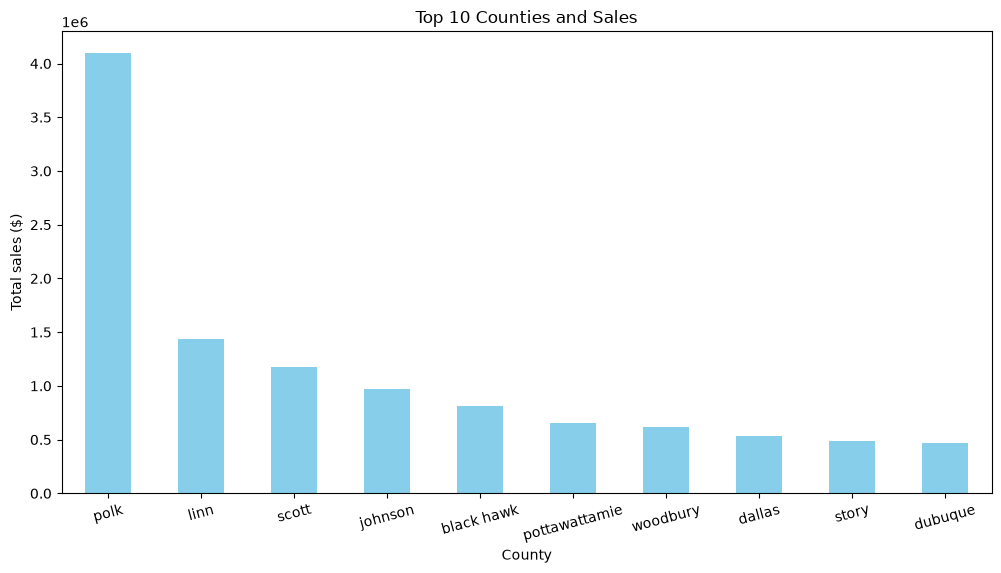

In [20]:
#Bar chart by county

sales_by_county.plot(kind="bar", figsize=(12,6), color="skyblue")
plt.title("Top 10 Counties and Sales")
plt.ylabel("Total sales ($)")
plt.xlabel("County")
plt.xticks(rotation=15)
plt.show()

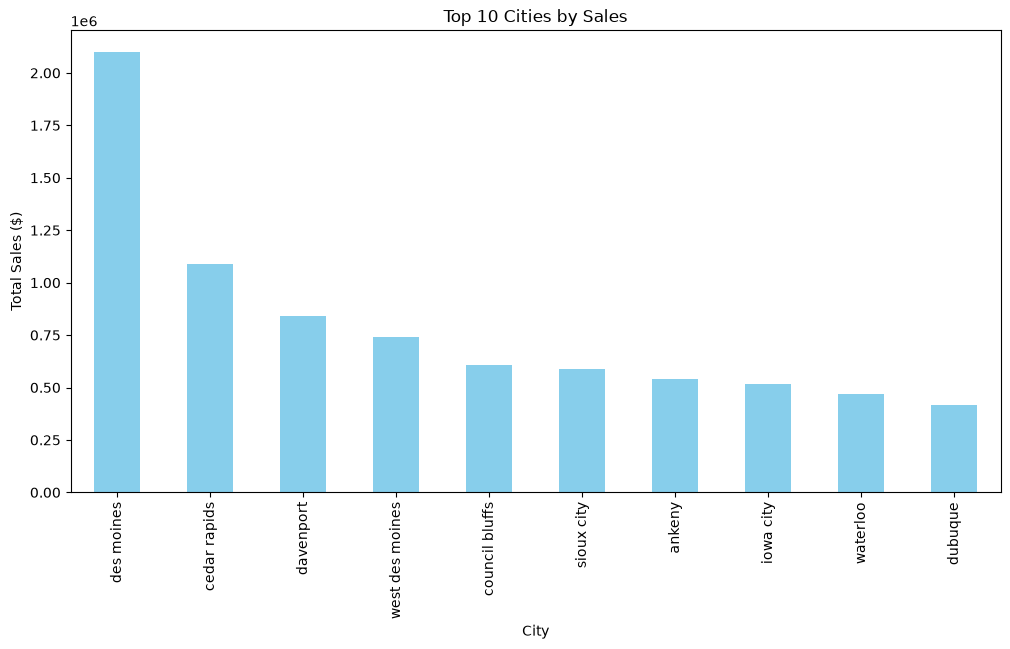

In [22]:
#Bar chart by city

sales_by_city.plot(kind="bar", figsize=(12,6), color="skyblue")
plt.title("Top 10 Cities by Sales")
plt.ylabel("Total Sales ($)")
plt.xlabel("City")
plt.show()

## By County

Highest sales: Polk County, with $4,094,964.29 in total sales.

Lowest sales (Top 10): Dubuque County, with $468,652.75.

Observation: Polk clearly dominates liquor sales, generating nearly 3x more than the second‑place county (Linn). The distribution shows a strong concentration of sales in urban counties.

## By City

Highest sales: Des Moines, with $2,097,932.30.

Lowest sales (Top 10): Dubuque, with $416,849.57.

Observation: Des Moines leads significantly, accounting for almost double the sales of Cedar Rapids (second place). Smaller cities like Dubuque contribute far less, highlighting the urban vs. regional disparity.

Distribution Insights

Sales are highly concentrated in major urban centers (Des Moines, Cedar Rapids, Davenport).

Counties and cities with larger populations and commercial hubs dominate liquor sales.

The distribution charts confirm a long‑tail pattern: a few regions drive most of the revenue, while smaller counties/cities contribute modestly.

## Temporal trends
How do sales change month-to-month?


In [ ]:
Is there seasonality (peaks in certain months)?

In [25]:
#Creay colum year-moth 

df['year_month']= df['date'].dt.to_period('M')

# Group sales by month
monthly_sales = (
    df.groupby('year_month')['sale_dollars']
    .sum()
    .reset_index()
)

print(monthy_sales)




   year_month  sale_dollars
0     2024-01     617464.81
1     2024-02     774285.56
2     2024-03     691923.38
3     2024-04     747650.72
4     2024-05     766026.27
5     2024-06     716826.83
6     2024-07     746815.92
7     2024-08     727723.37
8     2024-09     672994.89
9     2024-10     877715.26
10    2024-11     770055.37
11    2024-12     785378.60
12    2025-01     610667.94
13    2025-02     662210.61
14    2025-03     652539.62
15    2025-04     688061.86
16    2025-05     679971.50
17    2025-06     697325.12
18    2025-07     729979.43
19    2025-08     689100.71
20    2025-09     717385.98
21    2025-10     759541.34
22    2025-11     723029.65
23    2025-12     813549.98


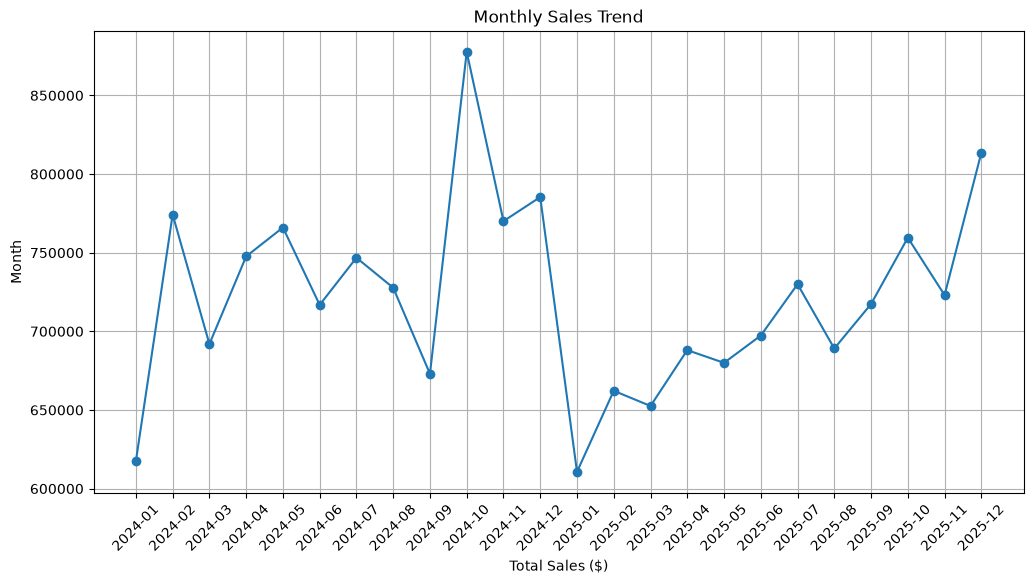

In [27]:
plt.figure(figsize=(12,6))
plt.plot(monthly_sales['year_month'].astype(str), monthly_sales['sale_dollars'], marker='o')
plt.title("Monthly Sales Trend")
plt.ylabel("Month")
plt.xlabel("Total Sales ($)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


## Monthly Sales Trend (2024–2025)
Sales show moderate fluctuations across months, with clear seasonal peaks.

In 2024, sales ranged from $617K in January to a high of $877K in October, with strong performance also in November and December.

In 2025, sales started lower ($610K in January) but gradually increased, reaching $813K in December.

Observation: Liquor sales tend to rise toward the end of each year, suggesting holiday season demand. Mid‑year months remain steady, while January consistently records the lowest sales.

### Is there seasonality (peaks in certain months)?
Sales data reveals a seasonal pattern: January consistently records the lowest sales, while October and December show significant peaks, highlighting holiday season demand.

## Top products and categories
What are the best-selling products?

In [30]:
item_description
titos handmade vodka                     1180033.42
black velvet                              448546.95
crown royal regal apple                   415209.94
fireball cinnamon whiskey                 381019.75
jack daniels old #7 black label           364104.42
crown royal                               314877.77
captain morgan original spiced            305034.51
captain morgan original spiced barrel     253949.37
patron silver                             246835.97
jameson                                   236238.17
top_products = (
    df.groupby("item_description")["sale_dollars"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

item_description
titos handmade vodka                     1180033.42
black velvet                              448546.95
crown royal regal apple                   415209.94
fireball cinnamon whiskey                 381019.75
jack daniels old #7 black label           364104.42
crown royal                               314877.77
captain morgan original spiced            305034.51
captain morgan original spiced barrel     253949.37
patron silver                             246835.97
jameson                                   236238.17
Name: sale_dollars, dtype: float64


In [35]:
#Top 10 products by bottles sold 

top_products_units = (
    df.groupby("item_description")["bottles_sold"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print("Products                                  bottles")
print(top_products_units)

Products                                  bottles
item_description
fireball cinnamon whiskey                121755
titos handmade vodka                      64385
black velvet                              40939
fireball cinnamon whiskey mini sleeve     33890
hawkeye vodka                             30543
mccormick 80prf vodka pet                 26853
captain morgan original spiced            19935
crown royal regal apple                   18326
99 bananas                                15538
jack daniels old #7 black label           14047
Name: bottles_sold, dtype: Int64


## Best‑Selling Products Summary

### By Sales Dollars

Tito’s Handmade Vodka is the clear leader with $1.18M, far ahead of the rest.

Other strong performers include Black Velvet ($448K), Crown Royal Regal Apple ($415K), and Fireball Cinnamon Whiskey ($381K).

Premium brands like Jack Daniels, Patrón Silver, and Jameson also appear in the top 10.

### By Bottles Sold

Fireball Cinnamon Whiskey dominates unit sales with 121,755 bottles, showing its popularity despite lower revenue compared to Tito’s.

Tito’s Handmade Vodka follows with 64,385 bottles, then Black Velvet (40,939 bottles).

Smaller, lower‑priced items like Fireball Mini Sleeve, Hawkeye Vodka, and McCormick Vodka rank high in bottles sold, reflecting consumer demand for affordable or compact formats.

### Which categories generate the most revenue?

In [39]:
# Top 10 categories by revenue

top_categories = (
    df.groupby("category_name")["sale_dollars"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(top_categories)


category_name
american vodkas                   2616654.12
canadian whiskies                 1854914.00
straight bourbon whiskies         1563191.20
100% agave tequila                1385711.57
whiskey liqueur                   1035021.59
spiced rum                         826017.42
tennessee whiskies                 663021.41
temporary & specialty packages     603166.97
imported cordials & liqueurs       481298.25
imported vodkas                    474264.77
Name: sale_dollars, dtype: float64


Vodka dominates overall revenue, with American Vodkas alone generating more than any other single category.

Whiskies collectively (Canadian, Bourbon, Tennessee, and Whiskey Liqueur) form a major share, highlighting strong demand for whiskey varieties.

Tequila also stands out, reflecting consumer interest in premium agave spirits.

Specialty and imported categories contribute less, but add diversity to the sales mix.

### Relationships between variablesIs there a correlation between sales volume and sales revenue?

### Which stores sell more bottles versus more liters?